In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True


## Histograms ##

In [2]:
top = Table.read_table('top_movies_2017.csv')
top

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [3]:
millions_col = np.round(top.column('Gross (Adjusted)')/1e6, 2)
millions_col

array([ 1796.18,  1583.48,  1266.07,  1261.08,  1204.37,  1164.59,
        1138.62,  1103.56,   983.23,   969.01,   961.14,   888.26,
         872.83,   871.22,   865.08,   836.19,   817.19,   802.87,
         792.51,   792.48,   787.  ,   760.78,   738.26,   702.75,
         701.62,   698.88,   695.04,   684.26,   683.47,   664.97,
         661.98,   655.01,   646.09,   632.73,   631.64,   627.26,
         622.28,   617.72,   615.8 ,   602.16,   599.22,   597.26,
         596.96,   589.41,   587.73,   584.2 ,   581.89,   574.55,
         574.43,   566.4 ,   562.2 ,   559.67,   557.8 ,   547.98,
         547.5 ,   545.63,   537.33,   536.08,   534.81,   533.4 ,
         533.4 ,   532.42,   530.78,   527.4 ,   524.96,   513.18,
         511.9 ,   511.88,   509.91,   505.88,   505.24,   504.01,
         499.25,   497.58,   497.07,   495.48,   494.07,   492.36,
         489.57,   489.31,   488.95,   488.08,   487.17,   486.18,
         485.54,   483.62,   479.18,   478.95,   478.35,   477

In [4]:
millions = top.select('Title').with_columns('Adjusted Gross', millions_col)
millions

Title,Adjusted Gross
Gone with the Wind,1796.18
Star Wars,1583.48
The Sound of Music,1266.07
E.T.: The Extra-Terrestrial,1261.08
Titanic,1204.37
The Ten Commandments,1164.59
Jaws,1138.62
Doctor Zhivago,1103.56
The Exorcist,983.23
Snow White and the Seven Dwarves,969.01


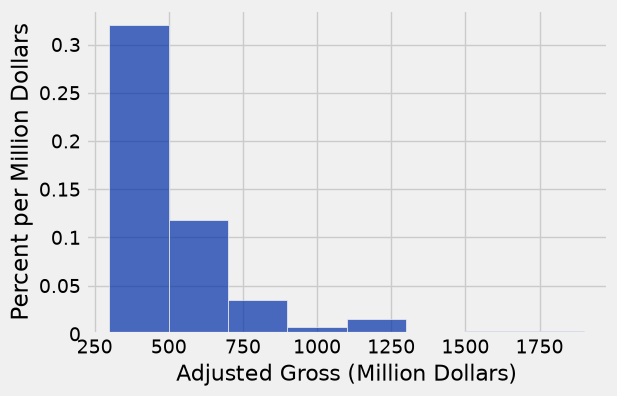

In [5]:
millions.hist('Adjusted Gross', bins=np.arange(300,2001,200), unit="Million Dollars")

# What is "percent per unit"?

In [6]:
millions_binned = millions.bin('Adjusted Gross', bins=np.arange(300,2001,200))
millions_binned

bin,Adjusted Gross count
300,128
500,47
700,14
900,3
1100,6
1300,0
1500,1
1700,1
1900,0


In [7]:
num_movies = top.num_rows
num_movies

200

In [8]:
# The percents correspond to the area of each bar
# So, the first bar accounts for 64% of the total area of the histogram
# The second bar accounts for 23.5% of the total area of the histogram, and so on
percents = (millions_binned.column('Adjusted Gross count') / num_movies) * 100
percents

array([ 64. ,  23.5,   7. ,   1.5,   3. ,   0. ,   0.5,   0.5,   0. ])

In [10]:
# These are the numbers that appear on the vertical axis
percents_per_unit = percents / 200 # our bin widths are all 200
percents_per_unit

array([ 0.32  ,  0.1175,  0.035 ,  0.0075,  0.015 ,  0.    ,  0.0025,
        0.0025,  0.    ])

# Why use percent per unit?

In [ ]:
# Plotting again with uneven bins
uneven = make_array(300, 350, 400, 500, 1800)
millions.hist('Adjusted Gross', bins=uneven, unit="Million Dollars")

In [ ]:
# Plotting the counts directly is misleading as a visualization since the eye picks 
# up area more than height
millions.hist('Adjusted Gross', bins=uneven, unit = 'Million Dollars', normed=False)

In [ ]:
# Another example of the area principle
some_tiny_bins = make_array(
    300, 350, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 1800)
millions.hist('Adjusted Gross', bins=some_tiny_bins, unit='Million Dollars')

# Practice
Produce a histogram that visualizes the ages (not the year of release) of the movies in top_movies. Use 10 automatically generated bins.
1. Produce an array that contains the age of each movie.
2. Attach the array as a new column to Table top.
3. Generate the histogram of your new column.